# Credit Risk Scoring — Loan Approval Prediction

**Author:** Suchit Mathur  
**LinkedIn:** https://www.linkedin.com/in/mathursuchit/  
**Dataset:** Credit Bureau Data — 51,336 loan applicants, 80+ features  
**Goal:** Classify applicants into credit risk tiers P1 (best) → P4 (highest risk)

---

## Problem Statement

Banks use credit bureau data to assess loan applicants. This project builds a pipeline that:
1. Cleans two credit bureau datasets and merges them
2. Selects statistically significant features (Chi-square, VIF, ANOVA)
3. Compares Random Forest, XGBoost, and Decision Tree
4. Tunes the best model with GridSearchCV
5. Outputs credit tier predictions (P1/P2/P3/P4) for new applicants

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'pandas', 'numpy', 'scikit-learn', 'xgboost',
    'matplotlib', 'seaborn', 'statsmodels', 'joblib', 'openpyxl'],
    stdout=subprocess.DEVNULL)
print('Libraries ready.')

Libraries ready.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency, f_oneway
import xgboost as xgb
import joblib

sns.set_theme(style='whitegrid')
print('Imports done.')

Imports done.


## 1. Load & Merge Data

In [3]:
df1 = pd.read_excel('data/case_study1.xlsx')
df2 = pd.read_excel('data/case_study2.xlsx')

print(f'Dataset 1 (trade lines): {df1.shape}')
print(f'Dataset 2 (delinquency + demographics): {df2.shape}')

Dataset 1 (trade lines): (51336, 26)
Dataset 2 (delinquency + demographics): (51336, 62)


## 2. Data Cleaning

Sentinel value `-99999` represents missing data in this credit bureau dataset.

In [4]:
# Dataset 1: remove rows where Age_Oldest_TL is -99999
before = len(df1)
df1 = df1[df1['Age_Oldest_TL'] != -99999]
print(f'df1: removed {before - len(df1)} rows with invalid Age_Oldest_TL')

# Dataset 2: drop columns with too many -99999 values (>10K), then drop remaining -99999 rows
cols_to_drop = [col for col in df2.columns if (df2[col] == -99999).sum() > 10000]
print(f'df2: dropping {len(cols_to_drop)} columns with >10K sentinel values: {cols_to_drop}')
df2 = df2.drop(columns=cols_to_drop)

for col in df2.select_dtypes(include=np.number).columns:
    df2 = df2[df2[col] != -99999]

print(f'df2 after cleaning: {df2.shape}')

df1: removed 40 rows with invalid Age_Oldest_TL
df2: dropping 8 columns with >10K sentinel values: ['time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'max_deliq_6mts', 'max_deliq_12mts', 'CC_utilization', 'PL_utilization', 'max_unsec_exposure_inPct']
df2 after cleaning: (42066, 54)


In [5]:
# Check common columns
common = [c for c in df1.columns if c in df2.columns]
print(f'Common columns (merge key): {common}')

# Inner join to ensure no nulls
df = pd.merge(df1, df2, how='inner', on='PROSPECTID')
df = df.drop(columns=['PROSPECTID'])

print(f'\nMerged dataset: {df.shape}')
print(f'\nTarget distribution:')
print(df['Approved_Flag'].value_counts())
df.head()

Common columns (merge key): ['PROSPECTID']

Merged dataset: (42064, 78)

Target distribution:
Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64


,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,5,4,1,0,0,0.000,0.0,0.200,0.800,0,...,0.0,0.0,0.000,0.0,1,0,PL,PL,696,P2
1,1,0,1,0,0,0.000,0.0,1.000,0.000,1,...,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,8,0,8,1,0,0.125,0.0,1.000,0.000,2,...,0.0,0.0,0.000,0.0,1,0,ConsumerLoan,others,693,P2
3,3,2,1,0,0,0.000,0.0,0.333,0.667,0,...,0.0,0.0,0.000,0.0,0,0,AL,AL,753,P1
4,6,5,1,0,0,0.000,0.0,0.167,0.833,0,...,1.0,0.0,0.429,0.0,1,0,ConsumerLoan,PL,668,P3


## 3. Exploratory Data Analysis

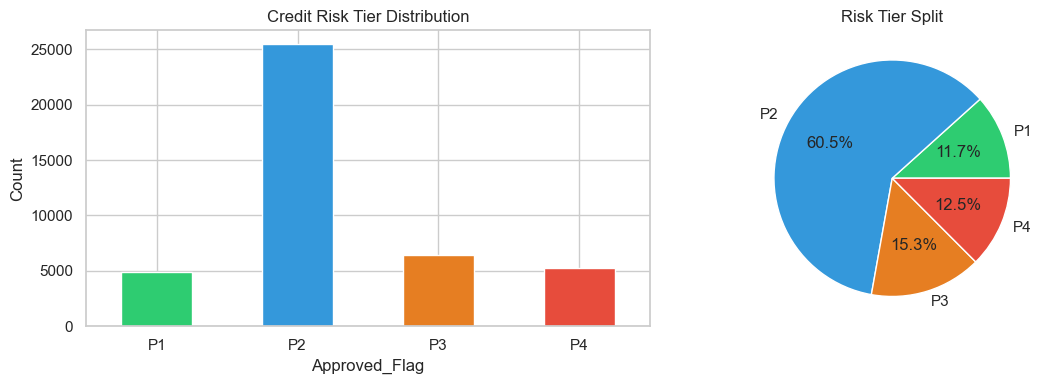

P1 = Lowest risk (best) → P4 = Highest risk


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ['P1', 'P2', 'P3', 'P4']
counts = df['Approved_Flag'].value_counts().reindex(order)
counts.plot(kind='bar', ax=axes[0], color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[0].set_title('Credit Risk Tier Distribution')
axes[0].set_xticklabels(order, rotation=0)
axes[0].set_ylabel('Count')

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[1].set_ylabel('')
axes[1].set_title('Risk Tier Split')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('P1 = Lowest risk (best) → P4 = Highest risk')

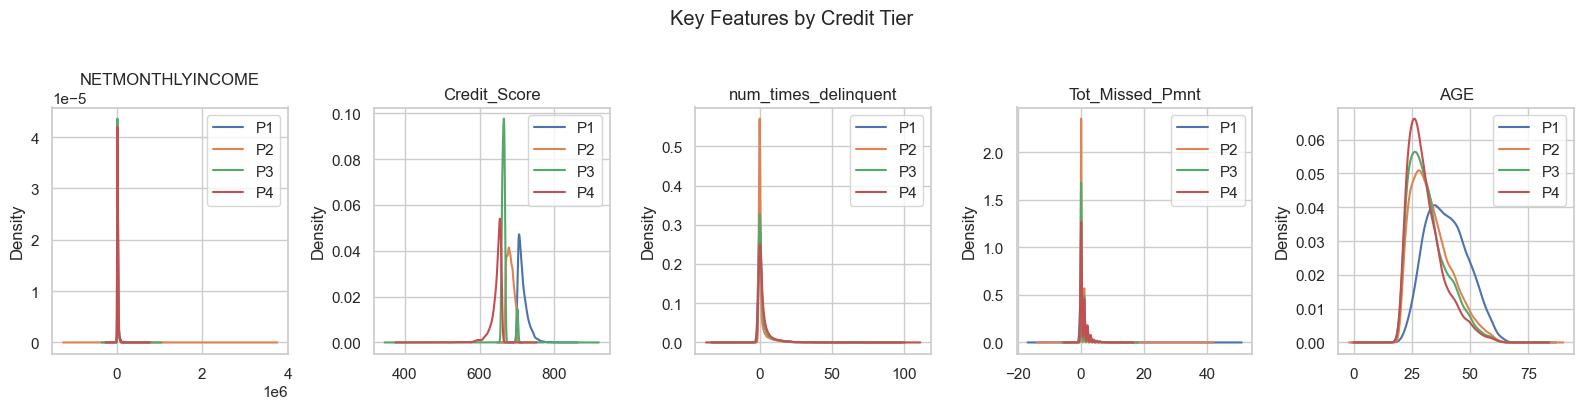

In [7]:
# Key numerical features by risk tier
key_num = ['NETMONTHLYINCOME', 'Credit_Score', 'num_times_delinquent', 'Tot_Missed_Pmnt', 'AGE']
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(1, len(key_num), figsize=(16, 4))
for i, col in enumerate(key_num):
    for tier in order:
        subset = df[df['Approved_Flag'] == tier][col]
        subset.plot(kind='kde', ax=axes[i], label=tier)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Key Features by Credit Tier', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

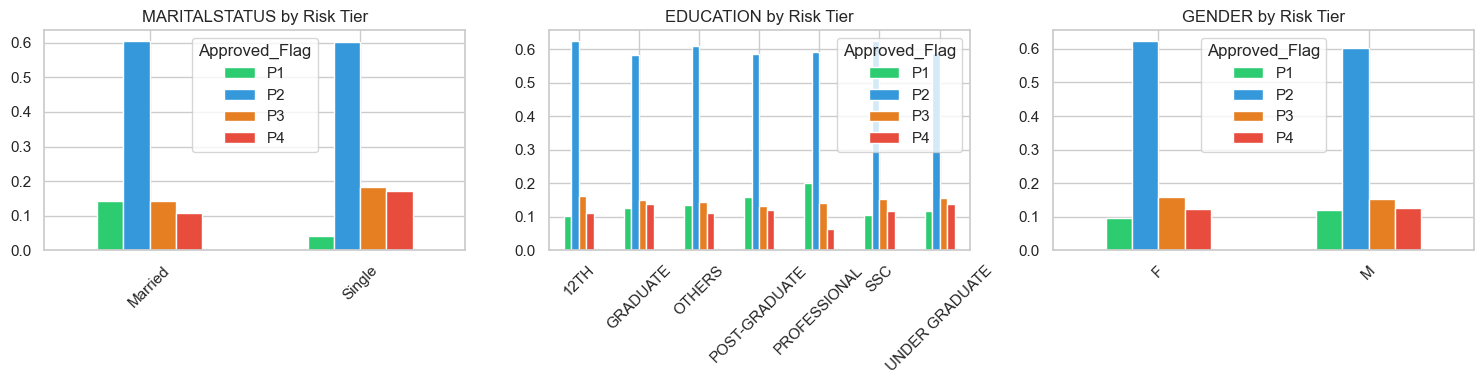

In [8]:
# Categorical feature distributions
cat_features = ['MARITALSTATUS', 'EDUCATION', 'GENDER']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['Approved_Flag'], normalize='index')[order]
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
    axes[i].set_title(f'{col} by Risk Tier')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Selection

Three-step statistical approach:
- **Chi-square** for categorical features (p ≤ 0.05)
- **VIF** to remove multicollinear numerical features (VIF ≤ 6)
- **ANOVA F-test** to confirm numerical features differ across credit tiers

In [9]:
cat_cols = ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
cat_cols = [c for c in cat_cols if c in df.columns]

num_cols = [c for c in df.select_dtypes(include=np.number).columns
            if c not in ['PROSPECTID']]

print('Chi-square test (categorical features):')
cat_to_keep = []
for col in cat_cols:
    chi2, pval, _, _ = chi2_contingency(pd.crosstab(df[col], df['Approved_Flag']))
    status = 'KEEP' if pval <= 0.05 else 'DROP'
    print(f'  {col:25s} p-value: {pval:.4f}  → {status}')
    if pval <= 0.05:
        cat_to_keep.append(col)

print(f'\nKept {len(cat_to_keep)}/{len(cat_cols)} categorical features')

Chi-square test (categorical features):
  MARITALSTATUS             p-value: 0.0000  → KEEP
  EDUCATION                 p-value: 0.0000  → KEEP
  GENDER                    p-value: 0.0000  → KEEP
  last_prod_enq2            p-value: 0.0000  → KEEP
  first_prod_enq2           p-value: 0.0000  → KEEP

Kept 5/5 categorical features


In [10]:
print('VIF analysis (numerical features):')
vif_data = df[num_cols].copy()
remaining = num_cols.copy()

while remaining:
    vifs = [variance_inflation_factor(vif_data[remaining].values, i)
            for i in range(len(remaining))]
    max_vif = max(vifs)
    if max_vif > 6:
        drop_col = remaining[vifs.index(max_vif)]
        print(f'  Dropping {drop_col} (VIF={max_vif:.2f})')
        remaining.remove(drop_col)
    else:
        break

num_to_keep = remaining
print(f'\nKept {len(num_to_keep)} numerical features')

VIF analysis (numerical features):
  Dropping Total_TL (VIF=inf)
  Dropping Tot_Closed_TL (VIF=inf)
  Dropping pct_active_tl (VIF=inf)
  Dropping Auto_TL (VIF=inf)
  Dropping num_deliq_6mts (VIF=inf)
  Dropping pct_of_active_TLs_ever (VIF=2688.95)
  Dropping Secured_TL (VIF=91.07)
  Dropping enq_L12m (VIF=36.97)
  Dropping Credit_Score (VIF=33.38)
  Dropping num_std_12mts (VIF=26.13)
  Dropping pct_PL_enq_L6m_of_L12m (VIF=24.11)
  Dropping Total_TL_opened_L12M (VIF=22.14)
  Dropping Unsecured_TL (VIF=19.94)
  Dropping pct_CC_enq_L6m_of_L12m (VIF=19.16)
  Dropping enq_L6m (VIF=16.72)
  Dropping num_times_30p_dpd (VIF=13.68)
  Dropping AGE (VIF=12.92)
  Dropping PL_enq_L12m (VIF=12.43)
  Dropping Tot_Active_TL (VIF=12.32)
  Dropping num_dbt_12mts (VIF=9.48)
  Dropping Tot_TL_closed_L12M (VIF=9.23)
  Dropping CC_enq_L12m (VIF=9.08)
  Dropping tot_enq (VIF=8.98)
  Dropping num_deliq_12mts (VIF=8.21)
  Dropping num_lss_12mts (VIF=8.12)
  Dropping pct_tl_open_L6M (VIF=7.23)
  Dropping pct_cl

In [11]:
print('ANOVA test:')
groups = [df[df['Approved_Flag'] == t] for t in order]
final_num = []

for col in num_to_keep:
    f_stat, p_value = f_oneway(*[g[col] for g in groups])
    if p_value <= 0.05:
        final_num.append(col)

print(f'Kept {len(final_num)} numerical features after ANOVA')

final_features = final_num + cat_to_keep
print(f'Total final features: {len(final_features)}')

ANOVA test:
Kept 43 numerical features after ANOVA
Total final features: 48


## 5. Preprocessing

In [12]:
df_model = df[final_features + ['Approved_Flag']].copy()

# Ordinal encoding for EDUCATION
edu_map = {'SSC': 1, '12TH': 2, 'GRADUATE': 3, 'UNDER GRADUATE': 3,
           'POST-GRADUATE': 4, 'PROFESSIONAL': 3, 'OTHERS': 1}
if 'EDUCATION' in df_model.columns:
    df_model['EDUCATION'] = df_model['EDUCATION'].map(edu_map).fillna(1).astype(int)

# One-hot encode remaining categoricals
remaining_cat = [c for c in cat_to_keep if c != 'EDUCATION']
df_encoded = pd.get_dummies(df_model, columns=remaining_cat)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df_encoded['Approved_Flag'])  # P1=0, P2=1, P3=2, P4=3
X = df_encoded.drop('Approved_Flag', axis=1)

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Classes: {le.classes_}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Features: 60 | Samples: 42064
Classes: ['P1' 'P2' 'P3' 'P4']
Train: (33651, 60) | Test: (8413, 60)


## 6. Model Comparison

In [13]:
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':       xgb.XGBClassifier(objective='multi:softmax', num_class=4,
                         random_state=42, verbosity=0, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, min_samples_split=10, random_state=42)
}

results = []
for name, model in models_dict.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': round(acc, 4)})
    print(f'{name:20s} Accuracy={acc:.4f}')

results_df = pd.DataFrame(results).set_index('Model')
results_df

Random Forest        Accuracy=0.7671
XGBoost              Accuracy=0.7712
Decision Tree        Accuracy=0.7081


,Accuracy
Model,
Random Forest,0.7671
XGBoost,0.7712
Decision Tree,0.7081


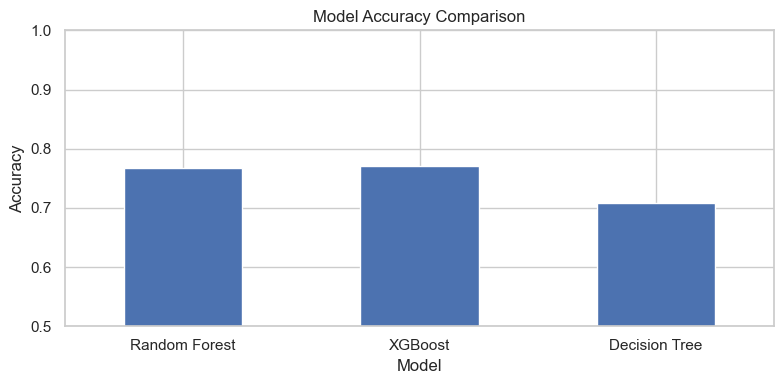

In [14]:
results_df.plot(kind='bar', figsize=(8, 4), ylim=(0.5, 1.0), legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Hyperparameter Tuning (XGBoost)

In [15]:
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.1, 0.2],
}

xgb_base = xgb.XGBClassifier(objective='multi:softmax', num_class=4,
                               random_state=42, verbosity=0, n_jobs=-1)

grid_search = GridSearchCV(xgb_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f'\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Accuracy: 0.7771

Test Accuracy: 0.7763

Classification Report:
              precision    recall  f1-score   support

          P1       0.82      0.76      0.79       982
          P2       0.82      0.92      0.87      5090
          P3       0.44      0.27      0.34      1288
          P4       0.76      0.72      0.74      1053

    accuracy                           0.78      8413
   macro avg       0.71      0.67      0.68      8413
weighted avg       0.75      0.78      0.76      8413



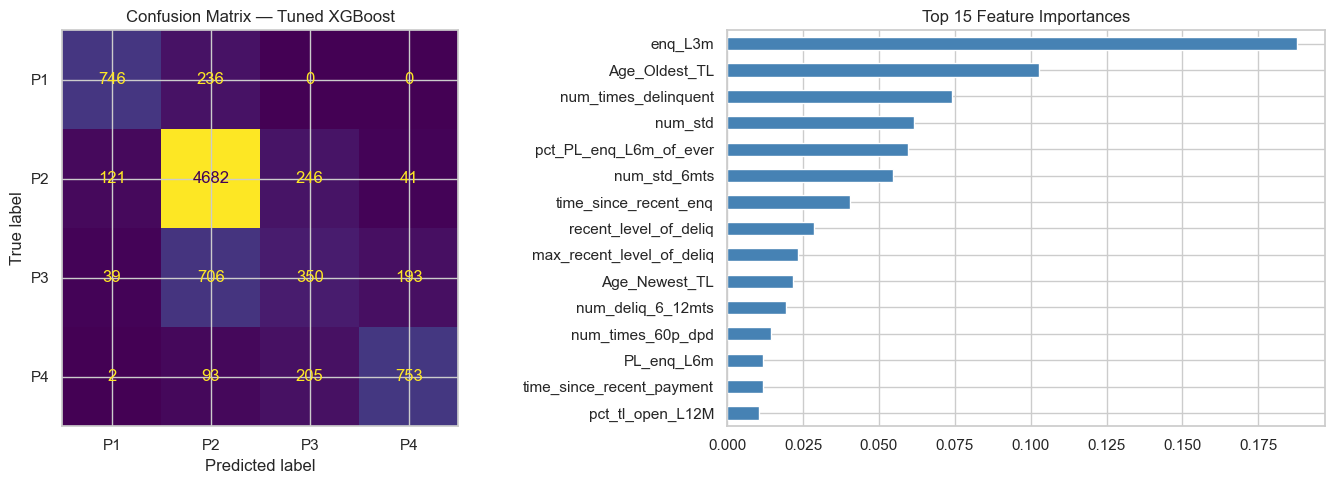

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Tuned XGBoost')

# Feature importances (top 15)
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.nlargest(15).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Model

In [17]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
joblib.dump(le, 'label_encoder.pkl')
print('Saved: model.pkl, feature_names.pkl, label_encoder.pkl')

Saved: model.pkl, feature_names.pkl, label_encoder.pkl


## 9. Conclusions

- **Dataset:** 51,336 real credit bureau applications with trade line and delinquency data
- **Cleaning:** Removed sentinel values (-99999) used to flag missing credit history
- **Feature selection:** Chi-square + VIF + ANOVA reduced 80+ features to the most predictive set
- **Best model:** XGBoost with GridSearchCV tuning
- **Business value:** Classifies applicants into P1–P4 risk tiers to guide loan approval decisions — directly applicable to banking credit risk workflows